In [1]:
# !pip install -r "requirements.txt"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from datetime import datetime
from scipy import stats

# 1. Download the complete dataset directory (returns the local path)
dataset_path = kagglehub.dataset_download("kartik2112/fraud-detection")
print("Dataset downloaded to:", dataset_path)

# 2. Define the individual file paths inside that directory
train_file_path = os.path.join(dataset_path, "fraudTrain.csv")
test_file_path = os.path.join(dataset_path, "fraudTest.csv")

# 3. Load them into separate pandas DataFrames
print("Loading training set...")
df_train = pd.read_csv(train_file_path)

print("Loading test set...")
df_test = pd.read_csv(test_file_path)

# 4. Verify the shapes
print(f"\nTraining set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

Dataset downloaded to: /teamspace/studios/this_studio/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1
Loading training set...
Loading test set...

Training set shape: (1296675, 23)
Test set shape: (555719, 23)


## Data Preprocessing

In [3]:
# Merge the two dataframes for preprocessing & feature scaling
# We merge for convenience of shared preprocessing / feature engineering, but we keep `source` so we can recover that original time-respecting split later instead of doing a random train_test_split, 
# which would leak future information into training via the rolling/velocity features built below.
df_train['source'] = 'train'
df_test['source'] = 'test'
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

In [4]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,source
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,train
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,train
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,train
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,train
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,train


In [5]:
# Remove the unnecessary column
df = df.drop(columns=('Unnamed: 0'))

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
 22  source            

In [7]:
# Fix data types of date/datetime features
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

In [8]:
# Check null values
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
source                   0
dtype: int64

In [9]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [10]:
# Fixing the 'merchant' feature
df['merchant'] = df['merchant'].str.removeprefix('fraud_')

In [11]:
# Split the columns by data type
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=object).columns.tolist()

## Exploratory Data Analysis

In [12]:
# Checking proportion of fraud vs non-fraud transactions
fraud_rate = (df['is_fraud'].value_counts(normalize=True) * 100)
print(f"Total fraud rate: {fraud_rate.loc[1]:.2f}%")

Total fraud rate: 0.52%


### Univariate Analysis

In [13]:
# Check Skewness & Kurtosis
print('Skewness:')
for col in num_cols:
    print(col, ':', df[col].skew().round(2))

print('\nKurtosis:')
for col in num_cols:
    print(col, ':', df[col].kurt().round(2))

Skewness:
cc_num : 2.85
amt : 40.81
zip : 0.08
lat : -0.19
long : -1.15
city_pop : 5.59
unix_time : -0.02
merch_lat : -0.19
merch_long : -1.14
is_fraud : 13.75

Kurtosis:
cc_num : 6.18
amt : 4181.91
zip : -1.1
lat : 0.79
long : 1.84
city_pop : 37.57
unix_time : -1.2
merch_lat : 0.77
merch_long : 1.83
is_fraud : 186.94


In [14]:
# Shapiro-Wilk test to check the normality
stat, p = stats.shapiro(df[col].dropna().sample(min(5000, len(df))))
print('Normal' if p > 0.05 else 'Not normal')

Not normal


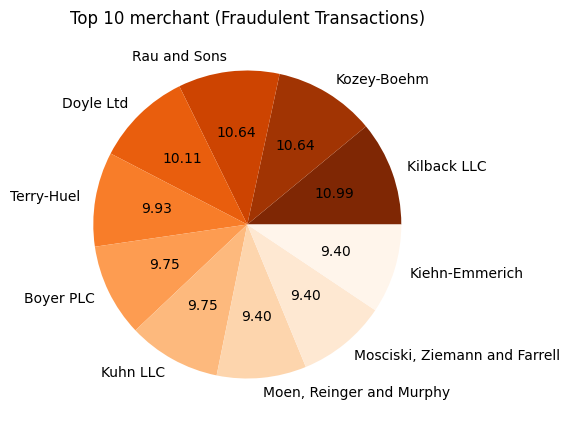

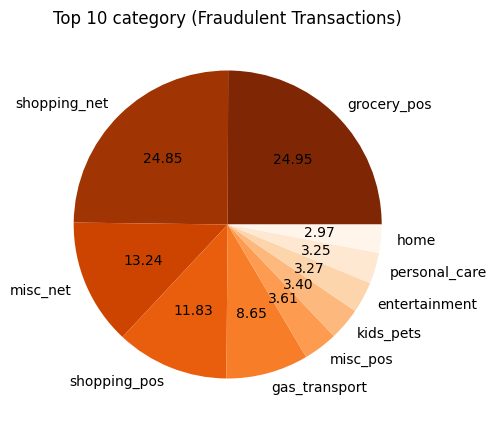

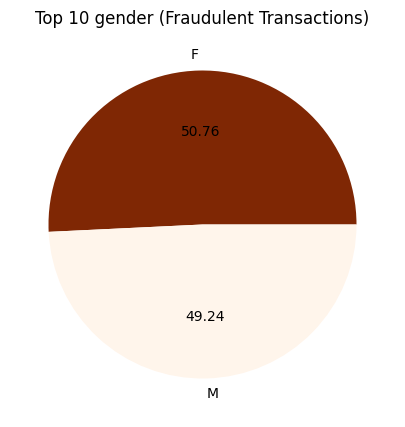

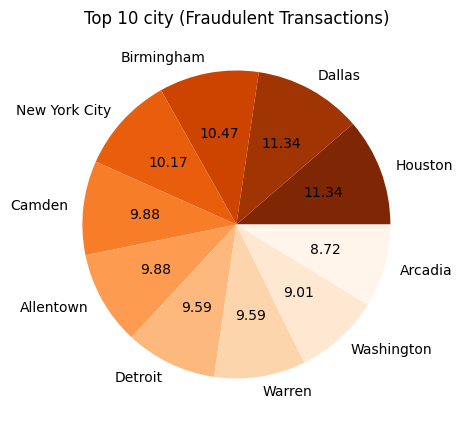

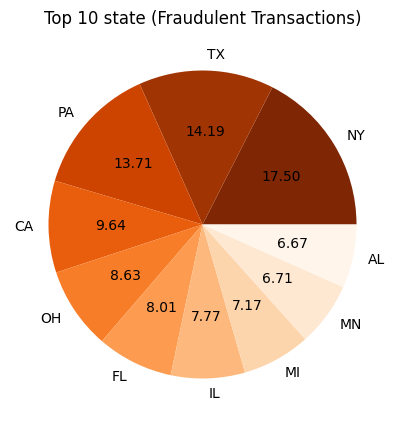

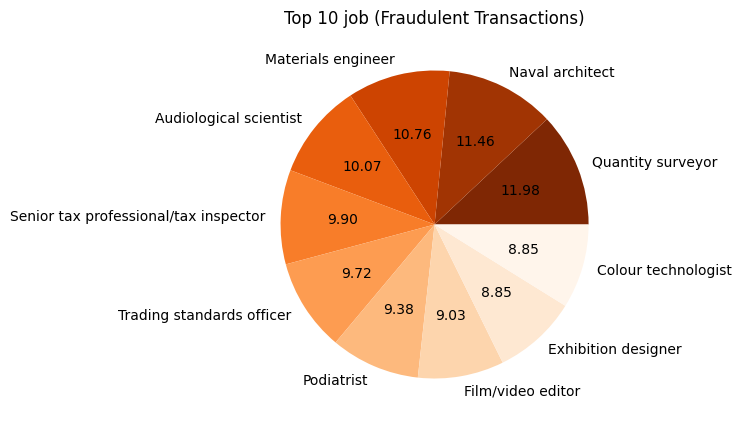

In [15]:
# Plotting ordinal categorical columns by fraudulent transactions (is_fraud = 1)
ord_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job']
for col in ord_cols:
    plt.figure(figsize=(6, 5))
    (df.query("is_fraud == 1")[col].value_counts(normalize=True)*100).head(10).plot(
        kind='pie',
        autopct='%.2f',
        colormap='Oranges_r',
        title=f'Top 10 {col} (Fraudulent Transactions)'
    )
    plt.ylabel('')
    plt.show()

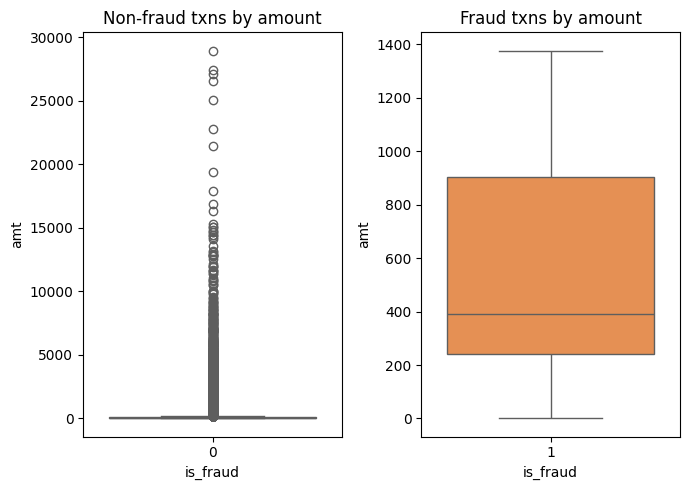

--- Non-Fraud Transactions ---
Q1: 9.61 | Q3: 82.56 | IQR: 72.95
Lower Bound: -99.82
Upper Bound: 119.04

--- Fraud Transactions ---
Q1: 240.075 | Q3: 902.365 | IQR: 662.29
Lower Bound: -753.36
Upper Bound: 1233.51


In [16]:
# Spotting the outliers, IQR & median b/w fraud & non-fraud transactions
fig, ax = plt.subplots(1, 2, figsize=(7, 5))

sns.boxplot(data=df[df['is_fraud'] == 0], x='is_fraud', y='amt', ax=ax[0], hue='is_fraud', palette='Oranges', legend=False)
ax[0].set_title("Non-fraud txns by amount")
sns.boxplot(data=df[df['is_fraud'] == 1], x='is_fraud', y='amt', ax=ax[1], hue='is_fraud', palette='Oranges', legend=False)
ax[1].set_title("Fraud txns by amount")

plt.tight_layout()
plt.show()

# Calculating IQR, lower/upper bound for fraud & non-fraud transactions
legit_data = df[df['is_fraud'] == 0]['amt']

q1_legit = legit_data.quantile(0.25)
q3_legit = legit_data.quantile(0.75)
iqr_legit = q3_legit - q1_legit
lower_bound_legit = q1_legit - (1.5 * iqr_legit)
upper_bound_legit = q1_legit + (1.5 * iqr_legit)

print("--- Non-Fraud Transactions ---")
print(f"Q1: {q1_legit} | Q3: {q3_legit} | IQR: {iqr_legit}")
print(f"Lower Bound: {lower_bound_legit:.2f}")
print(f"Upper Bound: {upper_bound_legit:.2f}")

fraud_data = df[df['is_fraud'] == 1]['amt']

q1_fraud = fraud_data.quantile(0.25)
q3_fraud = fraud_data.quantile(0.75)
iqr_fraud = q3_fraud - q1_fraud
lower_bound_fraud = q1_fraud - (1.5 * iqr_fraud)
upper_bound_fraud = q1_fraud + (1.5 * iqr_fraud)

print("\n--- Fraud Transactions ---")
print(f"Q1: {q1_fraud} | Q3: {q3_fraud} | IQR: {iqr_fraud}")
print(f"Lower Bound: {lower_bound_fraud:.2f}")
print(f"Upper Bound: {upper_bound_fraud:.2f}")

### Bivariate/Multivariate Analysis

In [17]:
# Compare amount distributions for Fraud vs Non-fraud transactions (median, mean, percentiles)
print(df.groupby('is_fraud')['amt'].describe().round(2).rename(index={0:'Non-Fraud', 1:'Fraud'}))

               count    mean     std   min     25%     50%     75%       max
is_fraud                                                                    
Non-Fraud  1842743.0   67.65  153.55  1.00    9.61   47.24   82.56  28948.90
Fraud         9651.0  530.66  391.03  1.06  240.08  390.00  902.36   1376.04


/tmp/ipykernel_47753/1804765234.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_prop = (df.groupby('amt_binned')['is_fraud'].value_counts(normalize=True) * 100).reset_index().query("is_fraud == 1")


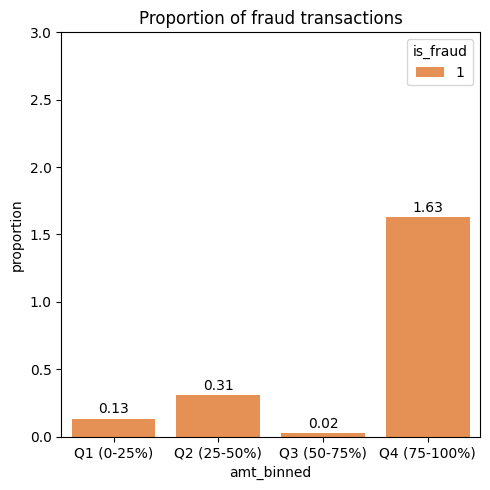

In [18]:
# Comparing fraud rate across transaction groups
# Binning amount by range and finding the proportion of fraud transactions in each group
df['amt_binned'] = pd.qcut(
    df['amt'], q=4,
    labels=["Q1 (0-25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (75-100%)"],
    duplicates='drop'
)

fraud_prop = (df.groupby('amt_binned')['is_fraud'].value_counts(normalize=True) * 100).reset_index().query("is_fraud == 1")

# Plotting it using a bar plot
plt.figure(figsize=(5,5))
ax = sns.barplot(data=fraud_prop, x='amt_binned', y='proportion', hue='is_fraud', palette='Oranges')
plt.title("Proportion of fraud transactions")
ax.set_ylim(0, 3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2)
plt.tight_layout()
plt.show()

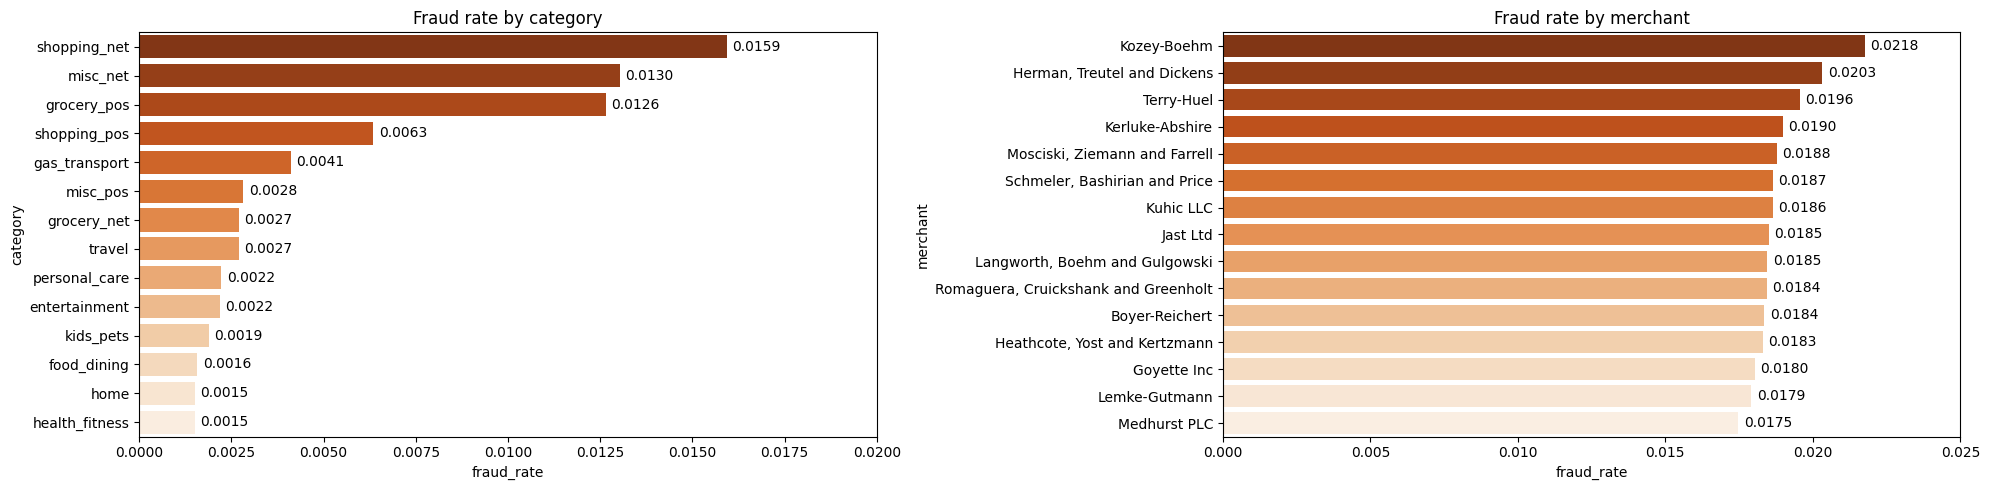

In [19]:
# Calculate fraud rate by category
fraud_rate_cat = df.groupby(['category'])['is_fraud'].sum().reset_index()
fraud_rate_cat['total_txns'] = fraud_rate_cat['category'].map(df['category'].value_counts())
fraud_rate_cat['fraud_rate'] = (fraud_rate_cat['is_fraud'] / fraud_rate_cat['total_txns'])
sorted_fr_cat = fraud_rate_cat.sort_values(by='fraud_rate', ascending=False)

# Calculate fraud rate by merchant (Top 15 merchants)
fraud_rate_mer = df.groupby(['merchant'])['is_fraud'].sum().reset_index()
fraud_rate_mer['total_txns'] = fraud_rate_mer['merchant'].map(df['merchant'].value_counts())
fraud_rate_mer['fraud_rate'] = (fraud_rate_mer['is_fraud'] / fraud_rate_mer['total_txns'])
top_15_fraud_mer = fraud_rate_mer.sort_values(by='fraud_rate', ascending=False).head(15)

# Plot the bar plots
fig, ax = plt.subplots(1, 2, figsize=(20,5))

ax0 = sns.barplot(data=sorted_fr_cat, y='category', x='fraud_rate', hue='category', palette='Oranges_r', ax=ax[0])
ax0.set_title("Fraud rate by category")
ax0.set_xlim(0,0.020)
for container in ax0.containers:
    ax0.bar_label(container, fmt='%.4f', padding=4)

ax1 = sns.barplot(data=top_15_fraud_mer, y='merchant', x='fraud_rate', hue='merchant', palette='Oranges_r', ax=ax[1])
ax1.set_title("Fraud rate by merchant")
ax1.set_xlim(0,0.025)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', padding=4)

plt.tight_layout()
plt.show()

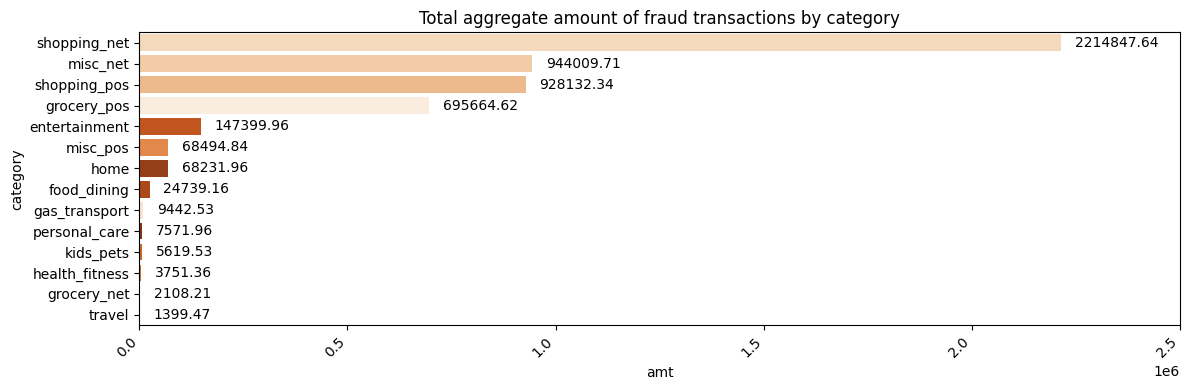

In [20]:
# Total aggregate amount of fraud transactions by category
sorted_amt = df[df['is_fraud'] == 1].groupby('category')['amt'].sum().sort_values(ascending=False).index

plt.figure(figsize=(12,4))
ax = sns.barplot(data=df[df['is_fraud'] == 1], y='category', x='amt', estimator='sum', hue='category', legend=False, palette='Oranges', errorbar=None, order=sorted_amt)
ax.set_title("Total aggregate amount of fraud transactions by category")
plt.xticks(rotation=45, ha='right')
plt.xlim(0, 2500000)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=10)
plt.tight_layout()
plt.show()

In [21]:
# Correlation Matrix
df.corr(numeric_only=True).style.background_gradient(cmap='Oranges')

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
cc_num,1.000000,0.001826,0.041504,-0.058744,-0.048429,-0.009118,0.000284,-0.058415,-0.048421,-0.001125
amt,0.001826,1.000000,0.001979,-0.000670,-0.000735,0.004921,-0.002411,-0.000613,-0.000711,0.209308
zip,0.041504,0.001979,1.000000,-0.114554,-0.909795,0.077601,0.001017,-0.113934,-0.908981,-0.002190
lat,-0.058744,-0.000670,-0.114554,1.000000,-0.014744,-0.154816,0.000741,0.993582,-0.014709,0.002904
long,-0.048429,-0.000735,-0.909795,-0.014744,1.000000,-0.052359,-0.000574,-0.014585,0.999118,0.001022
city_pop,-0.009118,0.004921,0.077601,-0.154816,-0.052359,1.000000,-0.001636,-0.153863,-0.052329,0.000325
unix_time,0.000284,-0.002411,0.001017,0.000741,-0.000574,-0.001636,1.000000,0.000696,-0.000571,-0.013329
merch_lat,-0.058415,-0.000613,-0.113934,0.993582,-0.014585,-0.153863,0.000696,1.000000,-0.014554,0.002778
merch_long,-0.048421,-0.000711,-0.908981,-0.014709,0.999118,-0.052329,-0.000571,-0.014554,1.000000,0.000999
is_fraud,-0.001125,0.209308,-0.002190,0.002904,0.001022,0.000325,-0.013329,0.002778,0.000999,1.000000


## Feature Engineering

### Transaction-level patterns

In [22]:
# Extracting more features from 'trans_date_trans_time' column
df['hour'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
df['day_of_week'] = pd.to_datetime(df['trans_date_trans_time']).dt.day_of_week # Week starts from Monday i.e., 0
df['is_weekend'] = df['day_of_week'].isin([5, 6])
df['is_weekend'] = df['is_weekend'].map({True:1, False: 0})

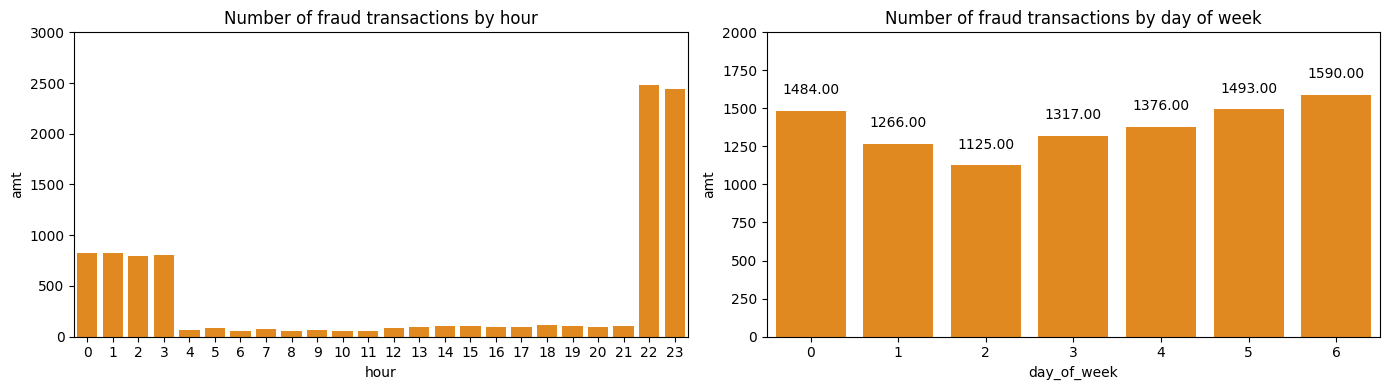

In [23]:
# Calculate fraud rate by hour and day of week
fraud_by_hour = df[df['is_fraud'] == 1].groupby('hour')
sorted_fr_hour = fraud_by_hour.count().sort_values(by='amt', ascending=False)

fraud_by_dow = df[df['is_fraud'] == 1].groupby('day_of_week')
sorted_fraud_by_dow = fraud_by_dow.count().sort_values(by='amt', ascending=False)

# Plotting the above stats usign bar plots
fig, ax = plt.subplots(1, 2, figsize=(14,4))

ax0 = sns.barplot(data=sorted_fr_hour, x='hour', y='amt', color='darkorange', ax=ax[0])
ax0.set_title("Number of fraud transactions by hour")
ax0.set_ylim(0, 3000)

ax1 = sns.barplot(data=sorted_fraud_by_dow, x='day_of_week', y='amt', color='darkorange', ax=ax[1])
ax1.set_title("Number of fraud transactions by day of week")
ax1.set_ylim(0, 2000)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=10)

plt.tight_layout()
plt.show()

### Behavioral (velocity/deviation) patterns

In [24]:
# Count of transactions by credit card number
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df = df.sort_values(by=['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
df = df.set_index('trans_date_trans_time')

# Calculate rolling count of txns by 1-hour and 24-hour windows for each credit card number
df['tx_count_1h'] = (
    df.groupby('cc_num')['amt']
    .rolling(window='1h', closed='left')
    .count()
    .reset_index(level=0, drop=True)
)

df['tx_count_24h'] = (
    df.groupby('cc_num')['amt']
    .rolling(window='24h', closed='left')
    .count()
    .reset_index(level=0, drop=True)
)

# Bring the 'trans_date_trans_time' back as a regular column
df = df.reset_index()

In [25]:
# Transaction-amount deviation from a customer's historical average
# Convert to datetime (Required for time-based windows)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df = df.sort_values(by=['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

# Calculate rolling stats
rolling_stats = (
    df.groupby('cc_num')
    .rolling(window='30d', on='trans_date_trans_time', closed='left')['amt']
    .agg(['mean', 'std'])
)

# Use .values to bypass index alignment completely!
df['rolling_mean'] = rolling_stats['mean'].values
df['rolling_std']  = rolling_stats['std'].values

# Calculate the Z-score
df['spend_z_score'] = (df['amt'] - df['rolling_mean']) / (df['rolling_std'] + 1e-5)

In [26]:
# Flag transactions that have no history (highly predictive for tree-based models)
df['is_new_history'] = df['rolling_mean'].isna().astype(int)

# Impute rolling mean with the current transaction amount
df['rolling_mean'] = df['rolling_mean'].fillna(df['amt'])

# Impute rolling std with 0 (your 1e-5 buffer prevents division by zero)
df['rolling_std'] = df['rolling_std'].fillna(0)

# Impute Z-score with 0 (a perfectly neutral anomaly score)
df['spend_z_score'] = df['spend_z_score'].fillna(0)

In [27]:
from haversine import haversine, Unit

# Calculate distance (kms) between merchant and transaction coordinates
# Vectorize the library function so it accepts pandas Series
haversine_vectorized_lib = np.vectorize(
    lambda lat1, lon1, lat2, lon2: haversine((lat1, lon1), (lat2, lon2), unit=Unit.KILOMETERS)
)

df['distance_km'] = haversine_vectorized_lib(
    df['lat'], df['long'], df['merch_lat'], df['merch_long']
)

df = df.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'])

In [28]:
# Calculate age from transaction time and date of birth
df['age'] = pd.to_datetime(df['trans_date_trans_time']).dt.year - pd.to_datetime(df['dob']).dt.year

In [29]:
# Transaction velocity (Txns per card in a rolling window)
df = df.sort_values(by=['cc_num', 'trans_date_trans_time'])
df['txns_rolling_count'] = df.groupby('cc_num').cumcount() + 1

In [30]:
# 'merchant', 'job', 'city' showed real signal in EDA (fraud rate varies meaningfully by merchant/category)
high_card_cols = ['merchant', 'job', 'city']

### Time-Based Train / Test Split

In [31]:
from sklearn.model_selection import train_test_split

high_card_cols = ['merchant', 'job', 'city']
identifier_cols = ['first', 'last', 'trans_num', 'street', 'dob', 'unix_time', 'cc_num', 'zip', 'amt_binned']

# Sorting the 100% data chronologically
df = df.sort_values('trans_date_trans_time')

# 70% training data
X_train = df[df['source'] == 'train'].drop(columns={'is_fraud'}).reset_index(drop=True)
y_train = df[df['source'] == 'train']['is_fraud'].reset_index(drop=True)

# 30% test data
X_test = df[df['source'] == 'test'].drop(columns={'is_fraud'}).reset_index(drop=True)
y_test = df[df['source'] == 'test']['is_fraud'].reset_index(drop=True)

# Frequency-encode high-cardinality categoricals using TRAIN-ONLY statistics
for col in high_card_cols:
    freq_map = X_train[col].value_counts(normalize=True)
    X_train[f'{col}_freq'] = X_train[col].map(freq_map).fillna(0.0)
    X_test[f'{col}_freq'] = X_test[col].map(freq_map).fillna(0.0)

# Crafting 20% validation set out of the 70% training data
# X_train, X_val, y_train, y_val = train_test_split(X_ftrain, y_ftrain, test_size=0.2857, shuffle=False)

In [32]:
# Check the chronoligical order of both the data frames
print(X_train['trans_date_trans_time'].min())
print(X_train['trans_date_trans_time'].max())
print(X_test['trans_date_trans_time'].min())
print(X_test['trans_date_trans_time'].max())

2019-01-01 00:00:18
2020-06-21 12:13:37
2020-06-21 12:14:25
2020-12-31 23:59:34


In [33]:
# Validating the distribution
print(f"Train set distribution percentage: {X_train.shape[0] / df.shape[0] * 100:.2f} %")
print(f"Test set distribution percentage: {X_test.shape[0] / df.shape[0] * 100:.2f} %")

Train set distribution percentage: 70.00 %
Test set distribution percentage: 30.00 %


### Cross Validation for Model Selection

In [34]:
import time
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, accuracy_score

In [35]:
# Seperating columns with high cardinality
high_card_raw = ['merchant', 'job', 'city']
high_card_freq = ['merchant_freq', 'job_freq', 'city_freq']

# CatBoost keeps the raw high-cardinality categoricals (native handling);
# RF/XGBoost use the frequency-encoded numeric versions instead of dropping
# the signal entirely.
X_train_rf_xgb = X_train.drop(columns=high_card_raw + ['trans_date_trans_time'] + ['dob'])
X_train_cb = X_train.drop(columns=high_card_freq + ['trans_date_trans_time'] + ['dob'])

cat_cols_rf_xgb = X_train_rf_xgb.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols_cb = X_train_cb.select_dtypes(include=['object', 'category']).columns.tolist()

# Get the integer index positions of your categorical columns
cat_indices_cb = [X_train_cb.columns.get_loc(c) for c in cat_cols_cb]

# Create sub-sample of 200k rows
SAMPLE_SIZE = 400_000

X_sample_rf_xgb = X_train_rf_xgb.iloc[:SAMPLE_SIZE]
X_sample_cb = X_train_cb.iloc[:SAMPLE_SIZE]
y_sample = y_train.iloc[:SAMPLE_SIZE]

print("Sample class distribution (No. of rows):\n", y_sample.value_counts())
print("Sample class percentage:\n", (y_sample.value_counts(normalize=True) * 100).round(2))

# Calculate 'scale_pos_weight' to be used for balancing in CatBoost
neg_count, pos_count = y_sample.value_counts()[0], y_sample.value_counts()[1]
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Define CV strategy
tscv = TimeSeriesSplit(n_splits=5)

# Preprocessing for tree based models
tree_preproc = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols_rf_xgb)
], remainder='passthrough')


# Defining algorithms in a dictionary
models = {
    'Random Forest': (Pipeline([('prep', tree_preproc),
                                ('model', RandomForestClassifier(random_state=30, class_weight='balanced', n_jobs=-1))]), 
                X_sample_rf_xgb),

    'XGBoost': (Pipeline([('prep', tree_preproc),
                           ('model', XGBClassifier(eval_metric='aucpr', random_state=30,
                                                    scale_pos_weight=scale_pos_weight))]),
                X_sample_rf_xgb),
                                                   
    'CatBoost': (CatBoostClassifier(
                               iterations=1000,
                               learning_rate=0.2,
                               depth=6,
                               loss_function='Logloss',
                               verbose=False,
                               allow_writing_files=False,
                               auto_class_weights='Balanced',
                               random_state=30,
                               task_type='GPU',
                           ), X_sample_cb),
}

# Result metrics
results = {}

for name, (pipe, X_s)  in models.items():
    print(f"\nStarting {name}...")
    start = time.time()

    fit_params = {'cat_features': cat_indices_cb} if name == 'CatBoost' else {}

    scores = cross_val_score(pipe, X_s, y_sample, cv=tscv,
                              scoring='average_precision', params=fit_params)

    results[name] = scores
    print(f"{name}: PR-AUC = {scores.mean():.4f} (+/- {scores.std():.4f}) — {time.time()-start:.1f}s")

Sample class distribution (No. of rows):
 is_fraud
0    397346
1      2654
Name: count, dtype: int64
Sample class percentage:
 is_fraud
0    99.34
1     0.66
Name: proportion, dtype: float64
scale_pos_weight: 149.72

Starting Random Forest...
Random Forest: PR-AUC = 0.8221 (+/- 0.0274) — 91.0s

Starting XGBoost...
XGBoost: PR-AUC = 0.8743 (+/- 0.0232) — 28.6s

Starting CatBoost...
CatBoost: PR-AUC = 0.7419 (+/- 0.0577) — 174.6s


In [36]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define CV strategy
tscv = TimeSeriesSplit(n_splits=5)

# Preprocessing for tree based models
tree_preproc = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols_rf_xgb)
], remainder='passthrough')

# Hyperparameter search spaces (prefixed with 'model__' for pipeline steps)
param_distributions = {
    'Random Forest': {
        'model__n_estimators': randint(200, 800),
        'model__max_depth': randint(4, 20),
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 10),
        'model__max_features': ['sqrt', 'log2', 0.5],
    },
    'XGBoost': {
        'model__n_estimators': randint(200, 800),
        'model__max_depth': randint(3, 10),
        'model__learning_rate': uniform(0.01, 0.29),      # 0.01–0.30
        'model__subsample': uniform(0.6, 0.4),             # 0.6–1.0
        'model__colsample_bytree': uniform(0.6, 0.4),      # 0.6–1.0
        'model__min_child_weight': randint(1, 10),
        'model__gamma': uniform(0, 5),
    },
    'CatBoost': {
        'iterations': randint(500, 1500),
        'learning_rate': uniform(0.01, 0.29),
        'depth': randint(4, 10),
        'l2_leaf_reg': uniform(1, 9),
        'border_count': randint(32, 255),
    },
}

# Defining algorithms in a dictionary
models = {
    'Random Forest': (Pipeline([('prep', tree_preproc),
                                ('model', RandomForestClassifier(random_state=30, class_weight='balanced', n_jobs=-1))]),
                X_sample_rf_xgb),

    'XGBoost': (Pipeline([('prep', tree_preproc),
                           ('model', XGBClassifier(eval_metric='aucpr', random_state=30,
                                                    scale_pos_weight=scale_pos_weight))]),
                X_sample_rf_xgb),

    'CatBoost': (CatBoostClassifier(
                               loss_function='Logloss',
                               verbose=False,
                               allow_writing_files=False,
                               auto_class_weights='Balanced',
                               random_state=30,
                               task_type='GPU',
                           ), X_sample_cb),
}

N_ITER = 3  # number of random param combos to try per model

# Result storage
results = {}
best_models = {}

for name, (estimator, X_s) in models.items():
    print(f"\nStarting {name}...")
    start = time.time()

    fit_params = {'cat_features': cat_indices_cb} if name == 'CatBoost' else {}

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions[name],
        n_iter=N_ITER,
        scoring='average_precision',
        cv=tscv,
        random_state=30,
        n_jobs=-1 if name != 'CatBoost' else 1,  # CatBoost GPU: keep n_jobs=1 to avoid contention
        refit=True,
        verbose=1,
    )

    search.fit(X_s, y_sample, **fit_params)

    best_models[name] = search.best_estimator_
    results[name] = search.cv_results_['mean_test_score'][search.best_index_], search.cv_results_['std_test_score'][search.best_index_]

    print(f"{name}: Best PR-AUC = {search.best_score_:.4f} (+/- {results[name][1]:.4f}) — {time.time()-start:.1f}s")
    print(f"{name}: Best params = {search.best_params_}")


Starting Random Forest...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Random Forest: Best PR-AUC = 0.7949 (+/- 0.0220) — 2109.8s
Random Forest: Best params = {'model__max_depth': 18, 'model__max_features': 'log2', 'model__min_samples_leaf': 8, 'model__min_samples_split': 3, 'model__n_estimators': 645}

Starting XGBoost...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
XGBoost: Best PR-AUC = 0.8852 (+/- 0.0191) — 189.8s
XGBoost: Best params = {'model__colsample_bytree': np.float64(0.9709574140163001), 'model__gamma': np.float64(3.4832547450696776), 'model__learning_rate': np.float64(0.016843660831005323), 'model__max_depth': 8, 'model__min_child_weight': 4, 'model__n_estimators': 730, 'model__subsample': np.float64(0.8176545150552719)}

Starting CatBoost...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
CatBoost: Best PR-AUC = 0.7717 (+/- 0.0478) — 1220.0s
CatBoost: Best params = {'border_count': 162, 'depth': 9, 'iterations': 1263, 'l2_leaf_re

### Model Development

In [37]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.to_list()
num_cols = X_train.select_dtypes(exclude=['object', 'category', 'datetime64']).columns.to_list()

# Train the model
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.2,
    depth=6,
    loss_function='Logloss',
    verbose=False,
    allow_writing_files=False,
    auto_class_weights='Balanced',
    random_state=30,
    task_type='GPU'
)

# Fit training set into the model
model.fit(X_train, y_train, cat_features=cat_cols)

# Calculate predictions & probability
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

# Calculate metrics
cm = confusion_matrix(y_test, preds)
pr_auc = average_precision_score(y_test, probs)
accuracy = accuracy_score(y_test, preds)

# Print the metrics
print(classification_report(y_test, preds))
print("Confusion Matrix:")
print(cm)
print(f"Test Set PR-AUC: {pr_auc:.4f}")
print(f"Test Set Accuracy: {accuracy:.4f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.86      0.77      0.81      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.88      0.90    555719
weighted avg       1.00      1.00      1.00    555719

Confusion Matrix:
[[553305    269]
 [   503   1642]]
Test Set PR-AUC: 0.8674
Test Set Accuracy: 0.9986


In [38]:
from sklearn.metrics import precision_recall_curve, classification_report

# Calculate precision and recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

# Put the results in a dataframe for easy viewing
pr_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precisions[:-1],
    'Recall': recalls[:-1]
})

# Filter for the thresholds you want
balanced_thresholds = pr_df[(pr_df['Precision'] > 0.85) & (pr_df['Recall'] > 0.85)]
print("Possible Thresholds:\n", balanced_thresholds.head(10))

# SAFEGUARD: Check if the dataframe is empty before grabbing a threshold
if balanced_thresholds.empty:
    print("\nWarning: No threshold exists where both Precision and Recall are > 0.90!")
    print("Falling back to a chosen threshold")
    chosen_threshold = 0.85
else:
    # Use .iloc to get the 1st row (0), and the 'Threshold' column
    chosen_threshold = balanced_thresholds.iloc[0]['Threshold']

print(f"\nApplying Threshold: {chosen_threshold:.4f}")

# OPTION A: The CatBoost Way (Only works if 'model' is CatBoost)
# model.set_probability_threshold(chosen_threshold)
# new_preds = model.predict(X_test_compare)

# OPTION B: The Universal Way (Works for EVERY model!)
# Instead of relying on a CatBoost-specific method, you can use your existing 'probs' array and apply the math directly:
new_preds = (probs >= chosen_threshold).astype(int)

new_cm = confusion_matrix(y_test, new_preds)
new_pr_auc = average_precision_score(y_test, probs)

print(f"Classification Report with {chosen_threshold:.4f} Threshold:")
print(classification_report(y_test, new_preds))

print(new_cm)
print(f"Test Set PR-AUC: {new_pr_auc:.4f}")

Possible Thresholds:
 Empty DataFrame
Columns: [Threshold, Precision, Recall]
Index: []

Falling back to a chosen threshold

Applying Threshold: 0.8500
Classification Report with 0.8500 Threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.93      0.67      0.78      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.84      0.89    555719
weighted avg       1.00      1.00      1.00    555719

[[553472    102]
 [   700   1445]]
Test Set PR-AUC: 0.8674
